**Purpose:** Assemble the Reddit sentiment training dataset from the labeling batches.

**Inputs:** `01_data/processed/reddit_0.parquet`, `data_syntheticposts/all_synthetic_labeled.parquet`, `dataset.parquet`, `dataset_augmented.parquet`

**Outputs:** `dataset.parquet`, `dataset_augmented.parquet`, `thesis/figs/reddit_token_distribution.png`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


In [1]:
import pandas as pd
import os
import json

In [2]:
files = [x for x in os.listdir(str(PROJECT_ROOT / "02_sentiment/labeling")) if x.startswith("reddit_") and x.endswith(".parquet")]

dfs = {"Qwen": [], "meta-llama": [], "google": []}
for file in files:
    key = file.split("_")[1]
    df = pd.read_parquet(os.path.join(str(PROJECT_ROOT / "02_sentiment/labeling"), file))
    dfs[key].append(df)

for key in dfs:
    dfs[key] = pd.concat(dfs[key], axis=0)
    dfs[key] = dfs[key].set_index("reddit_post_id")
    
df_merged = dfs["meta-llama"].join(
    [dfs["google"], dfs["Qwen"]],
    how="outer",
)

In [3]:
import pandas as pd

sectors = {
    "Energy", "Materials", "Industrials", "Consumer Discretionary",
    "Consumer Staples", "Health Care", "Financials",
    "Information Technology", "Communication Services",
    "Utilities", "Real Estate"
}

valid_sentiment = {"neutral", "negative", "positive"}

models = [
    "google/gemma-7b-it",
    "Qwen/Qwen2.5-7B-Instruct",
    "meta-llama/Llama-3.1-8B-Instruct"
]

new_rows = {}

for i, row in df_merged.iterrows():
    model_outputs = {m: row[m] for m in models}

    # skip if any model output is NaN
    if any(pd.isna(model_outputs[m]) for m in models):
        continue

    new_row = {}
    save = True

    for sector in sectors:
        cell_content = []

        for m in models:
            sentiment = model_outputs[m].get(sector)

            if sentiment not in valid_sentiment:
                save = False
                break

            cell_content.append(sentiment)

        if not save:
            break

        new_row[f"label_{sector}"] = cell_content

    if save:
        new_rows[i] = new_row

# Create DataFrame with index = original i
labels = pd.DataFrame.from_dict(new_rows, orient="index")

print("After filtering errors and NaNs:", labels.shape)
labels.sample(3)

After filtering errors and NaNs: (19019, 11)


,label_Utilities,label_Communication Services,label_Health Care,label_Financials,label_Real Estate,label_Consumer Staples,label_Industrials,label_Materials,label_Energy,label_Consumer Discretionary,label_Information Technology
iu6b21,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, negative, negative]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[positive, neutral, neutral]","[neutral, neutral, neutral]"
dhms90,"[neutral, neutral, neutral]","[neutral, neutral, positive]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, positive]"
3lgn86,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[positive, neutral, neutral]","[neutral, neutral, positive]"


In [4]:
reddit_posts = pd.read_parquet(str(PROJECT_ROOT / "01_data/processed/reddit_0.parquet"))
reddit_posts["top_comments"] = reddit_posts["top_comments"].apply(json.loads)
reddit_posts["submission"] = reddit_posts["submission"].apply(json.loads)

def create_reddit_post(reddit_df):
    import html
    from datetime import datetime

    reddit_to_label = {}

    for i, row in reddit_df.iterrows():

        to_label_text = "[POST]\n"
        submission = row["submission"]

        to_label_text += f"Title:\n{html.unescape(submission['title'])}\n"
        to_label_text += f"Body:\n{html.unescape(submission['selftext'])}\n\n"

        to_label_text += "[COMMENTS]\n"
        comments = row["top_comments"]

        if not comments:
            to_label_text += "No comments available.\n"
        else:
            top_comments = [(com["body"], com["score"]) for com in comments]
            top_comments = sorted(top_comments, key=lambda x: x[1], reverse=True)
            comments = [com[0] for com in top_comments]

            com_count, char_count = 0, 0
            for comment in comments:
                clean_comment = html.unescape(comment.replace("\n", "; ").strip())
                to_label_text += f"Comment {com_count + 1}:\n"
                to_label_text += f"{clean_comment}\n"

                com_count += 1
                char_count += len(clean_comment)

                #if com_count >= 5 and char_count >= 500:
                if com_count >= 10 and char_count >= 1000:
                    break

        reddit_to_label[i] = {
            "thread": to_label_text,
            "subreddit": row["subreddit"],
            "timestamp_utc": datetime.utcfromtimestamp(int(row["submission"]["created_utc"])),
        }

    return pd.DataFrame.from_dict(reddit_to_label, orient="index", columns=["thread", "subreddit", "timestamp_utc"])
    
df = create_reddit_post(reddit_posts)
df.sample(3)

,thread,subreddit,timestamp_utc
tp8awj,[POST]\nTitle:\nGOOG or GOOGL?\nBody:\nI know ...,stocks,2022-03-27 00:19:08
obn3q1,[POST]\nTitle:\nIndex fund diversification ide...,stocks,2021-07-01 14:34:09
f6s9f1,[POST]\nTitle:\nSONY\nBody:\nIs the price righ...,stocks,2020-02-20 12:18:46


In [ ]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

# Load tokenizers
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
modernbert_tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")

# Get max lengths dynamically
bert_max_len = bert_tokenizer.model_max_length
modernbert_max_len = modernbert_tokenizer.model_max_length

# Token counts
bert_tokens = df['thread'].apply(lambda x: len(bert_tokenizer.tokenize(x)))
modernbert_tokens = df['thread'].apply(lambda x: len(modernbert_tokenizer.tokenize(x)))

# Plot
plt.figure(figsize=(12, 6))

# BERT subplot
plt.subplot(1, 2, 1)
plt.hist(bert_tokens, bins=4000, alpha=0.7)
plt.title(f'BERT Token Length Distribution (max={bert_max_len})')
plt.xlabel('Number of Tokens')
plt.xlim(0, 5000)
plt.axvline(x=bert_max_len, linestyle='--', label=f'Limit ({bert_max_len})')
plt.legend()
plt.ylabel('Frequency')

# ModernBERT subplot
plt.subplot(1, 2, 2)
plt.hist(modernbert_tokens, bins=4000, alpha=0.7)
plt.title(f'ModernBERT Token Length Distribution (max={modernbert_max_len})')
plt.xlabel('Number of Tokens')
plt.xlim(0, 5000)
plt.axvline(x=modernbert_max_len, linestyle='--', label=f'Limit ({modernbert_max_len})')
plt.axvline(x=1536, linestyle='--', label=f'Limit (1536)')
plt.legend()
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Stats
print(f"BERT: {(bert_tokens > bert_max_len).sum()} threads exceed limit "
      f"({(bert_tokens > bert_max_len).mean() * 100:.2f}%).")

print(f"ModernBERT: {(modernbert_tokens > modernbert_max_len).sum()} threads exceed limit "
      f"({(modernbert_tokens > modernbert_max_len).mean() * 100:.2f}%).")

print(f"ModernBERT: {(modernbert_tokens > 1536).sum()} threads exceed limit "
      f"({(modernbert_tokens > 1536).mean() * 100:.2f}%).")

/opt/anaconda3/envs/mcd_sentiment/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Token indices sequence length is longer than the specified maximum sequence length for this model (863 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (9998 > 8192). Running this sequence through the model will result in indexing errors


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

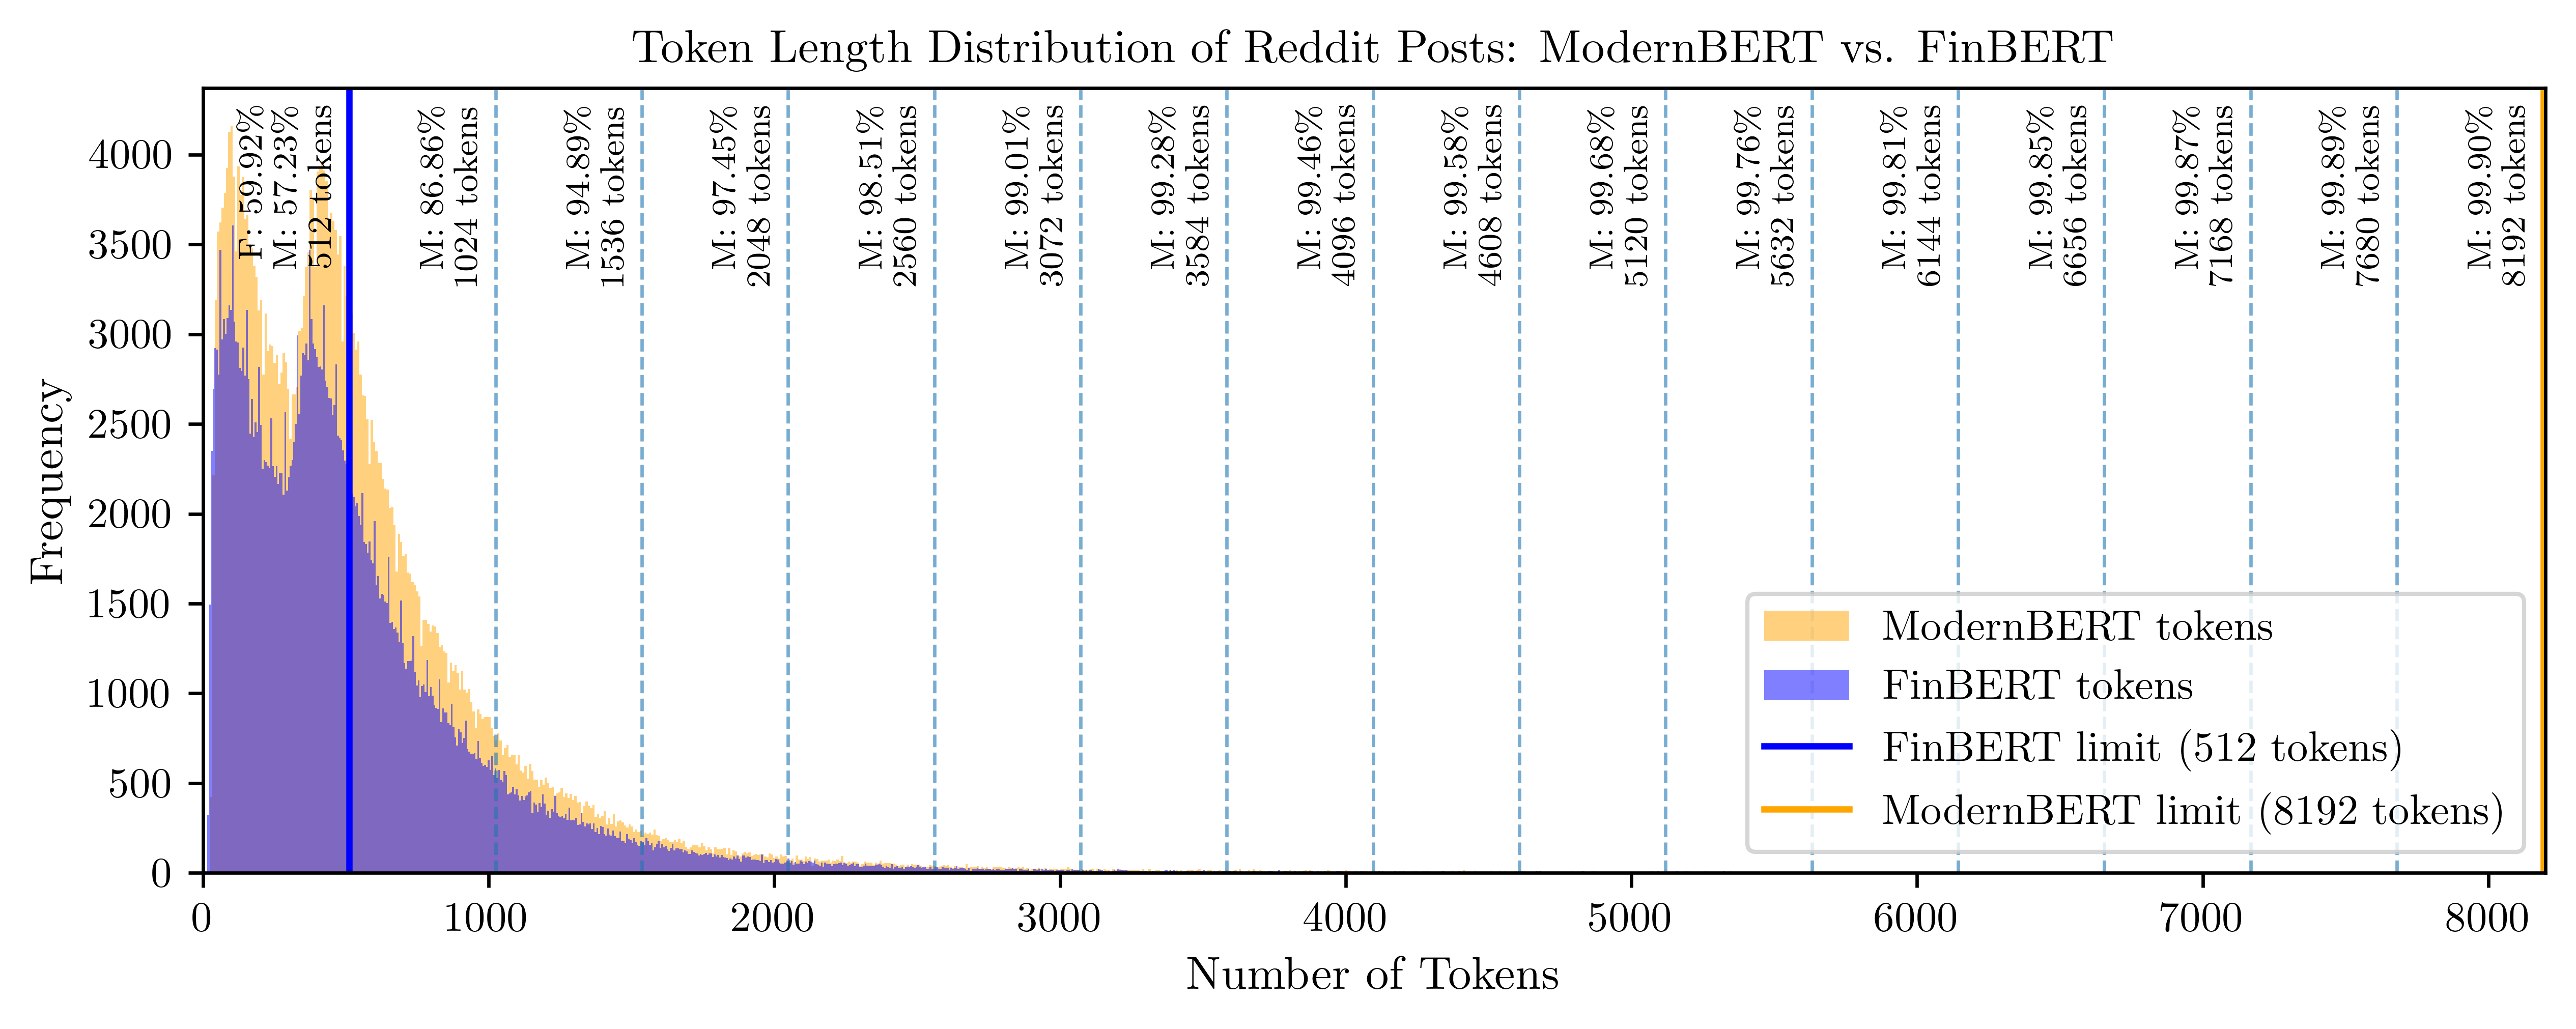

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Match your thesis: Latin Modern via LaTeX rendering
mpl.rcParams.update({
    # Use LaTeX for all text rendering
    "text.usetex": True,
    "font.family": "serif",

    # Latin Modern — matches your \usepackage{lmodern}
    "font.serif": ["Latin Modern Roman"],
    "font.sans-serif": ["Latin Modern Sans"],   # matches \sffamily in headings
    "font.monospace": ["Latin Modern Mono"],    # matches your TTT font

    # Match your thesis font size (11pt base)
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Load lmodern in the LaTeX preamble — critical for matching
    "pgf.preamble": "\n".join([
        r"\usepackage[utf8]{inputenc}",
        r"\usepackage[T1]{fontenc}",
        r"\usepackage{lmodern}",
    ]),

    # Line spacing loosely mirrors your \linespread{1.5}
    "figure.dpi": 600,  # matches your \pdfpxdimen=300dpi
})




plt.figure(figsize=(5.71*1.5, 3.5))  # 14.5cm × 8.9cm in inches

# Histograms
plt.hist(modernbert_tokens, bins=4000, alpha=0.5, label='ModernBERT tokens', color='orange')
plt.hist(bert_tokens, bins=4000, alpha=0.5, label='FinBERT tokens', color='blue')

plt.title('Token Length Distribution of Reddit Posts: ModernBERT vs. FinBERT')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.xlim(0, 8200)

# Convert to numpy (in case they aren't already)
modernbert_tokens = np.array(modernbert_tokens)
bert_tokens = np.array(bert_tokens)

y_max = plt.gca().get_ylim()[1]

for x in [512, 1024, 1536, 2048, 2560, 3072, 3584, 4096, 4608, 5120, 5632, 6144, 6656, 7168, 7680, 8192]:
    plt.axvline(x=x, linestyle='--', linewidth=0.8, alpha=0.6)

    # Compute cumulative %
    modern_pct = (modernbert_tokens <= x).mean() * 100
    finbert_pct = (bert_tokens <= x).mean() * 100

    if x == 512:
        label = f'F: {finbert_pct:.2f}\%\nM: {modern_pct:.2f}\%\n{x} tokens'
    else:
        label = f'M: {modern_pct:.2f}\%\n{x} tokens'

    plt.text(
        x - 40,
        y_max - 80,
        label,
        rotation=90,
        va='top',
        ha='right',
        fontsize=8,
    )

# Limits
plt.axvline(x=bert_max_len, color='blue', linestyle='-', linewidth=1.5, label=f'FinBERT limit ({bert_max_len} tokens)')
plt.axvline(x=modernbert_max_len, color='orange', linestyle='-', linewidth=1.5, label=f'ModernBERT limit ({modernbert_max_len} tokens)')

plt.legend()
plt.tight_layout()
# plt.savefig(str(PROJECT_ROOT / "thesis/figs/reddit_token_distribution.png"), bbox_inches="tight")
plt.show()

In [ ]:
df_merged = labels.merge(df[['thread']], left_index=True, right_index=True, how='inner')
df_merged

,label_Real Estate,label_Energy,label_Consumer Discretionary,label_Industrials,label_Materials,label_Consumer Staples,label_Health Care,label_Utilities,label_Financials,label_Communication Services,label_Information Technology,thread
10013dm,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, negative]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nDo Bear Markets end in Capitul...
1017myj,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, negative, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nBank Let Me Deposit Thousands ...
101lxsr,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nWhere are you investing your m...
102kjo7,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nGold rises to near six-month h...
102ongh,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, positive]",[POST]\nTitle:\nPull out of stocks or keep the...
...,...,...,...,...,...,...,...,...,...,...,...,...
zx6eio,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, positive, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nStryker\nBody:\nI have been wa...
zy8tjv,"[neutral, neutral, neutral]","[positive, positive, positive]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, positive]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nWill Nuclear Fusion Dump Clean...
zyjzsn,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]",[POST]\nTitle:\nBNDW vs PGBIX. What's a better...
zzyc96,"[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[neutral, neutral, neutral]","[POST]\nTitle:\nMy Christmas gift, gotta repre..."


In [ ]:
# df_merged.to_parquet("dataset.parquet")

In [ ]:
import pandas as pd
from collections import Counter

# Initialize a dictionary to hold totals
totals = {sector: {"positive": 0, "neutral": 0, "negative": 0} for sector in sectors}

def majority_sentiment(sent_list):
    counts = Counter(sent_list)
    most_common = counts.most_common()
    
    # Check for tie
    top_count = most_common[0][1]
    tied_sentiments = [sent for sent, count in most_common if count == top_count]
    
    if len(tied_sentiments) > 1:
        return "neutral"  # default to neutral on tie
    else:
        return most_common[0][0]

# Process each row
for _, row in df_merged.iterrows():
    for sector in sectors:
        # Directly access the list/array from the DataFrame
        sentiments = row["label_" + sector]
        # If it's a string accidentally, convert to list
        if isinstance(sentiments, str):
            sentiments = eval(sentiments)  # only if you really have a string
        maj = majority_sentiment(sentiments)
        totals[sector][maj] += 1

# Convert totals dict to DataFrame for easy viewing
totals_df = pd.DataFrame(totals).T  # transpose for sectors as rows
print(totals_df)

                        positive  neutral  negative
Real Estate                  137    18788        94
Energy                       319    18502       198
Consumer Discretionary       855    17628       536
Industrials                  223    18458       338
Materials                    144    18803        72
Consumer Staples              56    18934        29
Health Care                  372    18526       121
Utilities                     22    18982        15
Financials                   257    17922       840
Communication Services        93    18870        56
Information Technology      1240    17248       531


In [ ]:
import pandas as pd

real_data = pd.read_parquet("dataset.parquet")

def majority_vote(cell):
    votes = {"neutral": 0, "positive": 0, "negative": 0}
    for label in cell:
        if label in votes:
            votes[label] += 1
    majority_label = max(votes, key=votes.get)
    
    return majority_label if votes[majority_label] > 1 else "neutral"

for sector in [sec for sec in real_data.columns if sec.startswith("label_")]:
    real_data[sector] = real_data[sector].apply(majority_vote)


synthetic_data = pd.read_parquet("data_syntheticposts/all_synthetic_labeled.parquet")


new_dataset = pd.concat([real_data, synthetic_data])

# new_dataset.to_parquet("dataset_augmented.parquet")

new_dataset

,label_Information Technology,label_Health Care,label_Materials,label_Financials,label_Consumer Discretionary,label_Utilities,label_Communication Services,label_Real Estate,label_Consumer Staples,label_Energy,label_Industrials,thread
10013dm,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,[POST]\nTitle:\nDo Bear Markets end in Capitul...
1017myj,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,[POST]\nTitle:\nBank Let Me Deposit Thousands ...
101lxsr,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,[POST]\nTitle:\nWhere are you investing your m...
102kjo7,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,[POST]\nTitle:\nGold rises to near six-month h...
102ongh,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,[POST]\nTitle:\nPull out of stocks or keep the...
...,...,...,...,...,...,...,...,...,...,...,...,...
sy2190,neutral,neutral,neutral,neutral,negative,neutral,neutral,neutral,negative,neutral,neutral,[POST]\nTitle:\nStaples face talent competitio...
sy2191,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,negative,[POST]\nTitle:\nInventory mismanagement risks ...
sy2192,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,negative,neutral,neutral,[POST]\nTitle:\nHealth regulations could resha...
sy2193,neutral,neutral,neutral,neutral,negative,neutral,neutral,neutral,negative,neutral,neutral,[POST]\nTitle:\nStaples’ defensive reputation ...


In [ ]:
import pandas as pd
import json

data_all = pd.read_parquet("dataset_augmented.parquet")

with open(str(PROJECT_ROOT / "01_data/processed/reddit_gpt_validation_final.json"), "r") as f:
    reddit_gpt_validation_with_labels = json.load(f)
data_test_ids = list(reddit_gpt_validation_with_labels.keys())

data_test = data_all[data_all.index.isin(data_test_ids)]

data_train = data_all[~data_all.index.isin(data_test_ids)]


train_data_per_sector = {}
for sector in [sec for sec in data_train.columns if sec.startswith("label_")]:
    train_data_per_sector[sector] = dict(data_train[sector].value_counts())
train_data_per_sector = pd.DataFrame(train_data_per_sector).T.fillna(0).astype(int)
train_data_per_sector

,neutral,positive,negative
label_Information Technology,17097,1190,511
label_Health Care,18374,323,101
label_Materials,18582,111,105
label_Financials,17779,203,816
label_Consumer Discretionary,17442,807,549
label_Utilities,18588,103,107
label_Communication Services,18574,115,109
label_Real Estate,18584,106,108
label_Consumer Staples,18578,113,107
label_Energy,18338,287,173


In [ ]:
typess = {}
for i, row in data_train.iterrows():
    a = {"neutral": 0, "positive": 0, "negative": 0}
    for sector in [sec for sec in data_train.columns if sec.startswith("label_")]:
        if row[sector] == "negative":
            a["negative"] += 1
        elif row[sector] == "positive":
            a["positive"] += 1
        elif row[sector] == "neutral":
            a["neutral"] += 1

    a_str = f"neutral={a['neutral']}, positive={a['positive']}, negative={a['negative']}"
    typess[a_str] = typess.get(a_str, 0) + 1
type_distribution = pd.DataFrame({"type": list(typess.keys()), "count": list(typess.values())}).sort_values("count", ascending=False)
type_distribution["distribution"] = type_distribution["count"] / type_distribution["count"].sum()
type_distribution

,type,count,distribution
0,"neutral=11, positive=0, negative=0",13128,0.698372
1,"neutral=10, positive=1, negative=0",2796,0.148739
2,"neutral=10, positive=0, negative=1",2047,0.108895
3,"neutral=9, positive=0, negative=2",349,0.018566
5,"neutral=9, positive=2, negative=0",307,0.016332
4,"neutral=8, positive=0, negative=3",71,0.003777
6,"neutral=9, positive=1, negative=1",34,0.001809
10,"neutral=8, positive=3, negative=0",32,0.001702
7,"neutral=7, positive=0, negative=4",14,0.000745
11,"neutral=8, positive=1, negative=2",6,0.000319
